# Preprocessing & EDA — SE Asia Earthquake Catalog (7 Seismic Source Zones)

Self-contained pipeline from the two raw catalogs (TMD local + USGS regional)
through to exploratory analysis, structured as:

**Preprocess**
1. Merge files + remove duplicate events
2. Unify magnitude scale (convert everything to Mw)
3. Check data quality
4. Label each event by 7 seismic source zone

**EDA**
5. Magnitude vs. time per source zone (7 graphs)
6. Event count vs. time per source zone (7 graphs)
7. Resolution map — spatial data completeness (1 graph)

Run from the **repository root** (so `data/raw/...` resolves), with
`pandas`, `numpy`, `matplotlib`, `scipy` installed.


In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW_TMD = "data/raw/tmd_local_earthquake.csv"
RAW_USGS = "data/raw/usgs_combined_2012_2026.csv"
OUT_DIR = "data/processed"
FIG_DIR = "figures_v2"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

assert os.path.isfile(RAW_TMD) and os.path.isfile(RAW_USGS), (
    f"Raw files not found - run this notebook from the repo root (cwd={os.getcwd()})."
)


# Preprocess

## 1. Merge files + remove duplicate events

Loads both raw catalogs into one standardized schema, then removes events
that both networks reported independently (matched within 60s / 50km,
keeping the USGS record as network-of-record for shared events). Tracks how
many rows are dropped at each cleaning step along the way, for the data
quality check in Step 3.


In [2]:
def load_tmd():
    # TMD export is Windows-874 / TIS-620 encoded, not UTF-8.
    d = pd.read_csv(RAW_TMD, encoding="cp874")
    d.columns = [c.strip() for c in d.columns]
    steps = [("raw_rows", len(d))]

    out = pd.DataFrame()
    out["event_id"] = "TMD_" + d["REF. ID"].astype(str).str.strip()
    out["time_utc"] = pd.to_datetime(d["DATE-TIME UTC"], errors="coerce")
    out["lat"] = pd.to_numeric(d["LAT."], errors="coerce")
    out["lon"] = pd.to_numeric(d["LONG."], errors="coerce")
    out["depth_km"] = pd.to_numeric(d["DEPTH."], errors="coerce")
    out["mag"] = pd.to_numeric(d["MAG."], errors="coerce")
    out["mag_type"] = "ML(TMD)"
    out["network"] = "TMD"
    region_th = d["REGION."].astype(str).str.strip()
    region_en = d["REGION..1"].astype(str).str.strip() if "REGION..1" in d.columns else ""
    out["place"] = region_th.where(region_th.ne("") & region_th.ne("nan"), region_en)

    n = len(out)
    out = out.dropna(subset=["time_utc"]); steps.append(("dropped_unparseable_time", n - len(out))); n = len(out)
    out = out.dropna(subset=["lat", "lon"]); steps.append(("dropped_unparseable_latlon", n - len(out))); n = len(out)
    out = out[(out["lat"].between(-90, 90)) & (out["lon"].between(-180, 180))]
    steps.append(("dropped_out_of_range_latlon", n - len(out))); n = len(out)
    out = out.dropna(subset=["mag"]); steps.append(("dropped_unparseable_mag", n - len(out))); n = len(out)
    out = out[out["mag"] > 0]; steps.append(("dropped_mag_le_0", n - len(out))); n = len(out)
    steps.append(("kept", n))
    return out.reset_index(drop=True), steps


def load_usgs():
    d = pd.read_csv(RAW_USGS)
    steps = [("raw_rows", len(d))]

    d = d[d["type"] == "earthquake"]
    steps.append(("dropped_non_earthquake_type", steps[0][1] - len(d)))
    n = len(d)

    out = pd.DataFrame()
    out["event_id"] = "USGS_" + d["id"].astype(str)
    out["time_utc"] = pd.to_datetime(d["time"], errors="coerce", utc=True).dt.tz_localize(None)
    out["lat"] = pd.to_numeric(d["latitude"], errors="coerce")
    out["lon"] = pd.to_numeric(d["longitude"], errors="coerce")
    out["depth_km"] = pd.to_numeric(d["depth"], errors="coerce")
    out["mag"] = pd.to_numeric(d["mag"], errors="coerce")
    out["mag_type"] = d["magType"].astype(str)
    out["network"] = "USGS/" + d["net"].astype(str).str.upper()
    out["place"] = d["place"].astype(str)

    out = out.dropna(subset=["time_utc"]); steps.append(("dropped_unparseable_time", n - len(out))); n = len(out)
    out = out.dropna(subset=["lat", "lon"]); steps.append(("dropped_unparseable_latlon", n - len(out))); n = len(out)
    out = out[(out["lat"].between(-90, 90)) & (out["lon"].between(-180, 180))]
    steps.append(("dropped_out_of_range_latlon", n - len(out))); n = len(out)
    out = out.dropna(subset=["mag"]); steps.append(("dropped_unparseable_mag", n - len(out))); n = len(out)
    out = out[out["mag"] > 0]; steps.append(("dropped_mag_le_0", n - len(out))); n = len(out)
    steps.append(("kept", n))
    return out.reset_index(drop=True), steps


tmd, tmd_steps = load_tmd()
usgs, usgs_steps = load_usgs()
print(f"TMD:  {len(tmd)} events kept")
print(f"USGS: {len(usgs)} events kept")


TMD:  16656 events kept
USGS: 47151 events kept


In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


def dedupe(tmd_df, usgs_df, time_window_s=60, dist_window_km=50):
    """Flags TMD events within `time_window_s`s / `dist_window_km`km of a
    USGS event as duplicates (both networks pick up larger regional shocks)
    and drops them, keeping the USGS record. Also returns each matched
    pair's actual offset, for the dedup diagnostics in Step 3."""
    t = tmd_df.sort_values("time_utc").reset_index(drop=True)
    u = usgs_df.sort_values("time_utc").reset_index(drop=True)
    u_times = u["time_utc"].values; u_lat = u["lat"].values; u_lon = u["lon"].values

    window = np.timedelta64(time_window_s, "s")
    is_dup = np.zeros(len(t), dtype=bool)
    matches = []
    lo = 0
    for i, ti in enumerate(t["time_utc"].values):
        while lo < len(u_times) and u_times[lo] < ti - window:
            lo += 1
        best = None
        jj = lo
        while jj < len(u_times) and u_times[jj] <= ti + window:
            d = haversine_km(t["lat"].iloc[i], t["lon"].iloc[i], u_lat[jj], u_lon[jj])
            if d <= dist_window_km:
                dt_s = abs((u_times[jj] - ti) / np.timedelta64(1, "s"))
                if best is None or d < best[0]:
                    best = (d, dt_s)
            jj += 1
        if best is not None:
            is_dup[i] = True
            matches.append((i, best[1], best[0]))
    match_df = pd.DataFrame(matches, columns=["tmd_index", "time_offset_s", "distance_km"])
    return t.loc[~is_dup].reset_index(drop=True), match_df


tmd_unique, dedup_matches = dedupe(tmd, usgs)
print(f"Dropped {len(dedup_matches)} TMD events as duplicates of a USGS event "
      f"(kept as {len(tmd) - len(dedup_matches)} unique TMD events).")

catalog = pd.concat([tmd_unique, usgs], ignore_index=True).sort_values("time_utc").reset_index(drop=True)
n_before = len(catalog)
catalog = catalog.drop_duplicates(subset=["network", "time_utc", "lat", "lon", "mag"])
print(f"Removed {n_before - len(catalog)} exact duplicate rows within the same network.")
print(f"\nMerged catalog: {len(catalog)} events, {catalog['time_utc'].min()} to {catalog['time_utc'].max()}")
assert catalog["event_id"].is_unique, "event_id should be unique after merging"
catalog.head()


Dropped 1270 TMD events as duplicates of a USGS event (kept as 15386 unique TMD events).
Removed 31 exact duplicate rows within the same network.

Merged catalog: 62506 events, 2007-01-04 08:38:00 to 2026-09-11 00:53:48.954000


,event_id,time_utc,lat,lon,depth_km,mag,mag_type,network,place
0,TMD_TM0001,2007-01-04 08:38:00,18.9,99.00,0.0,2.4,ML(TMD),TMD,อ.แม่ริม จ.เชียงใหม่
1,TMD_TM0002,2007-01-06 02:23:00,18.9,99.00,0.0,3.1,ML(TMD),TMD,อ.แม่ริม จ.เชียงใหม่
2,TMD_TM0003,2007-04-22 06:18:00,19.4,99.36,0.0,4.5,ML(TMD),TMD,อ.เวียงป่าเป้า จ.เชียงราย
3,TMD_TM0004,2007-04-23 14:18:00,19.6,99.20,0.0,4.0,ML(TMD),TMD,อ.พร้าว จ.เชียงใหม่
4,TMD_TM0005,2007-05-16 10:04:00,21.0,100.50,0.0,4.7,ML(TMD),TMD,พรมแดนลาว-พม่า


## 2. Unify magnitude scale

The two networks report different magnitude scales: TMD uses local
magnitude (ML), USGS reports a mix of body-wave (mb), local (ml), and
several moment-magnitude variants (mww, mwb, mwc, mwr - all
W-phase/centroid-moment estimates that are already Mw-equivalent by
construction). Comparing raw magnitudes across zones/networks is not valid,
so everything is converted to a single **unified Mw** column using the
global empirical regressions of Scordilis (2006):

- `Mw = 0.67*ML + 2.07` (calibrated for 3.0 <= ML <= 6.1)
- `Mw = 0.85*mb + 1.03` (calibrated for 3.5 <= mb <= 6.2)
- mww/mwb/mwc/mwr/mw pass through unchanged (already Mw)

These are first-order, off-the-shelf global relations (not fit to this
region), so each converted event is flagged when its original magnitude
falls outside the regression's calibration range - the conversion there is
an extrapolation and should be treated with caution (in particular, TMD's
catalog goes down to ML 0.6, far below the ML regression's calibrated
floor of 3.0).


Conversion method counts:
mag_unified_method
mb->Mw (Scordilis 2006)                43609
ML->Mw (Scordilis 2006)                15436
passthrough (already Mw-equivalent)     3461

Events converted outside the regression's calibration range (extrapolated): 9522 (15.2%)


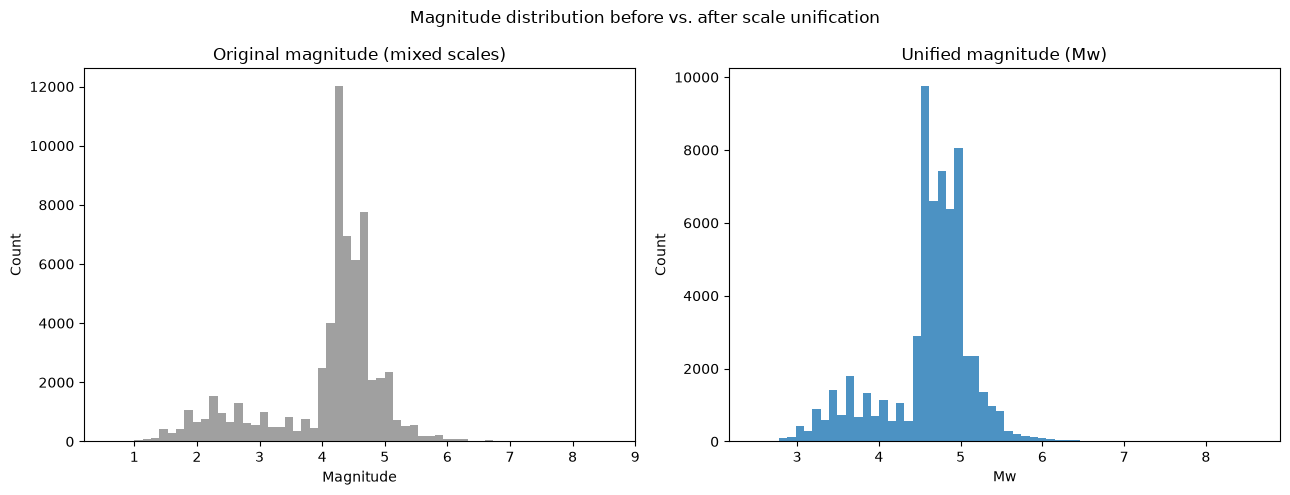

In [4]:
def unify_magnitude(mag, mag_type):
    mt = str(mag_type).strip().lower()
    if mt in ("mww", "mwb", "mwc", "mwr", "mw"):
        return mag, "passthrough (already Mw-equivalent)", False
    if mt in ("ml(tmd)", "ml"):
        mw = 0.67 * mag + 2.07
        return mw, "ML->Mw (Scordilis 2006)", not (3.0 <= mag <= 6.1)
    if mt == "mb":
        mw = 0.85 * mag + 1.03
        return mw, "mb->Mw (Scordilis 2006)", not (3.5 <= mag <= 6.2)
    return mag, "unknown_type_passthrough", True


results = [unify_magnitude(m, t) for m, t in zip(catalog["mag"], catalog["mag_type"])]
catalog["mag_unified"] = [r[0] for r in results]
catalog["mag_unified_method"] = [r[1] for r in results]
catalog["mag_unified_extrapolated"] = [r[2] for r in results]

print("Conversion method counts:")
print(catalog["mag_unified_method"].value_counts().to_string())
n_extrap = catalog["mag_unified_extrapolated"].sum()
print(f"\nEvents converted outside the regression's calibration range (extrapolated): "
      f"{n_extrap} ({n_extrap / len(catalog) * 100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(catalog["mag"], bins=60, color="#888", alpha=0.8)
axes[0].set_title("Original magnitude (mixed scales)")
axes[0].set_xlabel("Magnitude"); axes[0].set_ylabel("Count")
axes[1].hist(catalog["mag_unified"], bins=60, color="#1f77b4", alpha=0.8)
axes[1].set_title("Unified magnitude (Mw)")
axes[1].set_xlabel("Mw"); axes[1].set_ylabel("Count")
fig.suptitle("Magnitude distribution before vs. after scale unification")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/00_magnitude_unification.png", dpi=150)
plt.show()


## 3. Check data quality

Four checks: how many rows were dropped at each cleaning filter (Step 1),
how the magnitude types (and now the extrapolation flag from Step 2) are
distributed across networks, whether the dedup time/distance cutoffs used
in Step 1 are well chosen, and a final sanity pass over the merged catalog.


In [5]:
audit = pd.DataFrame(
    [{"source": "TMD", "step": s, "count": c} for s, c in tmd_steps] +
    [{"source": "USGS", "step": s, "count": c} for s, c in usgs_steps]
)
print("Rows dropped per cleaning filter step:")
audit


Rows dropped per cleaning filter step:


,source,step,count
0,TMD,raw_rows,16656
1,TMD,dropped_unparseable_time,0
2,TMD,dropped_unparseable_latlon,0
3,TMD,dropped_out_of_range_latlon,0
4,TMD,dropped_unparseable_mag,0
5,TMD,dropped_mag_le_0,0
6,TMD,kept,16656
7,USGS,raw_rows,47151
8,USGS,dropped_non_earthquake_type,0
9,USGS,dropped_unparseable_time,0


In [6]:
comp = catalog.groupby(["network", "mag_type", "mag_unified_extrapolated"]).size().reset_index(name="count")
print("Magnitude-type composition by network (and whether the Mw conversion was an extrapolation):")
comp


Magnitude-type composition by network (and whether the Mw conversion was an extrapolation):


,network,mag_type,mag_unified_extrapolated,count
0,TMD,ML(TMD),False,5859
1,TMD,ML(TMD),True,9515
2,USGS/OFFICIAL,mw,False,1
3,USGS/US,Mb,False,1
4,USGS/US,mb,False,43605
5,USGS/US,mb,True,3
6,USGS/US,ml,False,58
7,USGS/US,ml,True,4
8,USGS/US,mwb,False,126
9,USGS/US,mwc,False,59


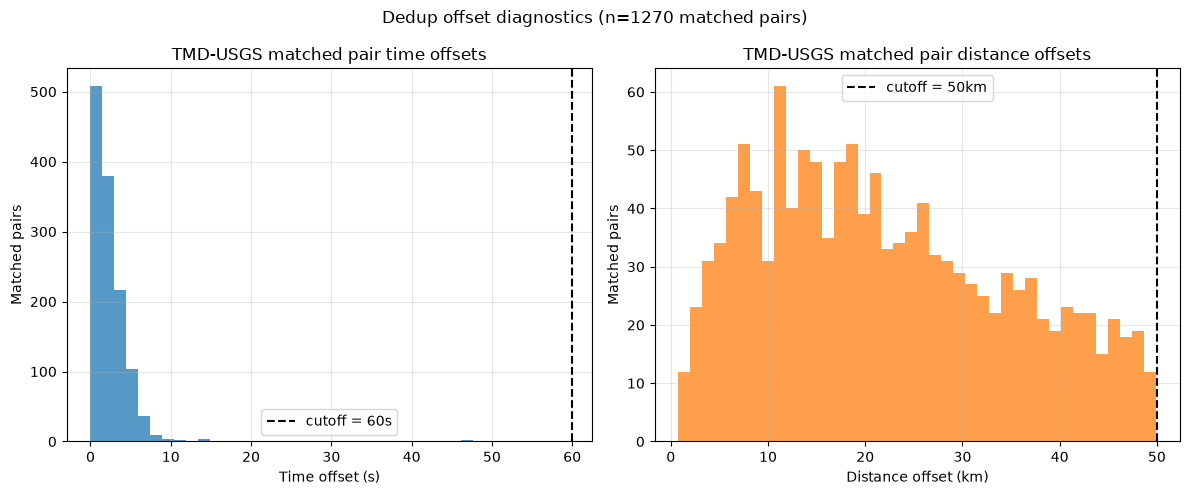

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(dedup_matches["time_offset_s"], bins=40, color="#1f77b4", alpha=0.75)
axes[0].axvline(60, color="k", ls="--", label="cutoff = 60s")
axes[0].set_xlabel("Time offset (s)"); axes[0].set_ylabel("Matched pairs")
axes[0].set_title("TMD-USGS matched pair time offsets"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(dedup_matches["distance_km"], bins=40, color="#ff7f0e", alpha=0.75)
axes[1].axvline(50, color="k", ls="--", label="cutoff = 50km")
axes[1].set_xlabel("Distance offset (km)"); axes[1].set_ylabel("Matched pairs")
axes[1].set_title("TMD-USGS matched pair distance offsets"); axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle(f"Dedup offset diagnostics (n={len(dedup_matches)} matched pairs)")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/00_dedup_offset_diagnostics.png", dpi=150)
plt.show()


In [8]:
print("Final sanity checks on the merged catalog:")
print(f"  Duplicate event_id:        {catalog['event_id'].duplicated().sum()} (expect 0)")
print(f"  Rows with mag <= 0:        {(catalog['mag'] <= 0).sum()} (expect 0)")
print(f"  Rows with mag_unified NaN: {catalog['mag_unified'].isna().sum()} (expect 0)")
print(f"  Lat out of [-90,90]:       {(~catalog['lat'].between(-90, 90)).sum()} (expect 0)")
print(f"  Lon out of [-180,180]:     {(~catalog['lon'].between(-180, 180)).sum()} (expect 0)")
print(f"  Time range:                {catalog['time_utc'].min()} to {catalog['time_utc'].max()}")
print(f"  Total events:              {len(catalog)}")

catalog.to_csv(f"{OUT_DIR}/catalog_clean_unified.csv", index=False)
print(f"\nSaved -> {OUT_DIR}/catalog_clean_unified.csv")


Final sanity checks on the merged catalog:
  Duplicate event_id:        0 (expect 0)
  Rows with mag <= 0:        0 (expect 0)
  Rows with mag_unified NaN: 0 (expect 0)
  Lat out of [-90,90]:       0 (expect 0)
  Lon out of [-180,180]:     0 (expect 0)
  Time range:                2007-01-04 08:38:00 to 2026-09-11 00:53:48.954000
  Total events:              62506



Saved -> data/processed/catalog_clean_unified.csv


## 4. Label each event by 7 seismic source zone

7 literature-informed, first-order approximation seismic source zones for
Southeast Asia (coarse linear boundaries / bounding boxes - good enough for
EDA, but should be refined against an authoritative fault database, e.g.
the GEM Global Active Faults Database, before spatial-probability
modeling), matching `scripts/02_source_zones.py` elsewhere in this project:

| Code | Zone |
|---|---|
| Z1 | Sunda Megathrust - Sumatra Segment |
| Z2 | Great Sumatran Fault Zone |
| Z3 | Sunda Megathrust - Java to Nusa Tenggara |
| Z4 | Andaman-Nicobar-Myanmar Arc & Sagaing Fault System |
| Z5 | Shan-Thai / Indochina Intraplate Zone |
| Z6 | Philippine Mobile Belt |
| Z7 | Sulawesi - Molucca Sea - Banda Arc |


In [9]:
ZONES = [
    {"id": 1, "code": "Z1", "name": "Sunda Megathrust - Sumatra Segment"},
    {"id": 2, "code": "Z2", "name": "Great Sumatran Fault Zone"},
    {"id": 3, "code": "Z3", "name": "Sunda Megathrust - Java to Nusa Tenggara"},
    {"id": 4, "code": "Z4", "name": "Andaman-Nicobar-Myanmar Arc & Sagaing Fault System"},
    {"id": 5, "code": "Z5", "name": "Shan-Thai / Indochina Intraplate Zone"},
    {"id": 6, "code": "Z6", "name": "Philippine Mobile Belt"},
    {"id": 7, "code": "Z7", "name": "Sulawesi - Molucca Sea - Banda Arc"},
]
ZONE_NAME = {z["code"]: z["name"] for z in ZONES}
ZONE_ORDER = [z["code"] for z in ZONES]
ZONE_COLOR = {
    "Z1": "#d62728", "Z2": "#ff7f0e", "Z3": "#2ca02c", "Z4": "#1f77b4",
    "Z5": "#9467bd", "Z6": "#8c564b", "Z7": "#17becf",
}


def sumatra_coast_lon(lat):
    """Approx. west-coast-of-Sumatra longitude as a function of latitude,
    anchored on Banda Aceh (95.3, 5.5) and Bengkulu (102.3, -3.8)."""
    return 99.44 - 0.7527 * lat


def classify(lat, lon):
    # Z4: Andaman Sea / Myanmar Indo-Burma arc / Sagaing fault
    if 92.0 <= lon <= 98.5 and 6.5 <= lat <= 28.5:
        return "Z4"
    # Z1 / Z2: Sumatra megathrust (offshore, incl. outer-rise/forearc
    # seismicity) vs Sumatran Fault (onshore), split by a linearized
    # paleo-coastline running NW-SE. Longitude capped at 105.5 so the
    # Sunda Strait / Lampung tip does not bleed into western Java (Z3).
    if -7.0 <= lat <= 6.5 and lon <= 105.5:
        coast = sumatra_coast_lon(lat)
        if coast - 10.0 <= lon < coast - 0.3:
            return "Z1"
        if coast - 0.3 <= lon <= coast + 3.0:
            return "Z2"
    # Z5: mainland SE Asia intraplate (Thailand, Laos, Cambodia, Vietnam,
    # southern Yunnan, Malay Peninsula)
    if 97.0 <= lon <= 110.0 and 5.0 <= lat <= 23.5:
        return "Z5"
    # Z3: Java to Nusa Tenggara megathrust
    if 105.0 <= lon <= 126.0 and -11.5 <= lat <= -6.0:
        return "Z3"
    # Z6: Philippine Mobile Belt (incl. Manila Trench, Luzon-Taiwan collision)
    if 118.0 <= lon <= 127.5 and 4.0 <= lat <= 25.5:
        return "Z6"
    # Z7: Sulawesi - Molucca Sea - Banda Arc (eastern Indonesia)
    if 113.0 <= lon <= 135.0 and -11.0 <= lat <= 6.5:
        return "Z7"
    return "Unclassified"


checks = [
    ("Bangkok, Thailand", 13.75, 100.50, "Z5"),
    ("Chiang Mai, Thailand", 18.79, 98.98, "Z5"),
    ("Yangon, Myanmar", 16.80, 96.15, "Z4"),
    ("Banda Aceh, Indonesia (N. Sumatra)", 5.55, 95.32, "Z2"),
    ("Offshore W. Sumatra (2004 rupture area)", 3.30, 95.85, "Z1"),
    ("Jakarta, Indonesia (Java)", -6.21, 106.85, "Z3"),
    ("Manila, Philippines", 14.60, 120.98, "Z6"),
    ("Manado, N. Sulawesi", 1.49, 124.85, "Z7"),
]
print("Sanity check:")
for name, lat, lon, expected in checks:
    got = classify(lat, lon)
    print(f"  {'OK' if got == expected else 'MISMATCH':8s} {name:25s} -> {got} (expected {expected})")

catalog["zone_code"] = [classify(la, lo) for la, lo in zip(catalog["lat"], catalog["lon"])]
catalog["zone_name"] = catalog["zone_code"].map(ZONE_NAME).fillna("Outside defined source zones")

print("\nEvent counts by zone:")
print(catalog["zone_code"].value_counts().reindex(ZONE_ORDER + ["Unclassified"]).to_string())

catalog.to_csv(f"{OUT_DIR}/catalog_clean_unified_zoned.csv", index=False)
print(f"\nSaved -> {OUT_DIR}/catalog_clean_unified_zoned.csv")


Sanity check:
  OK       Bangkok, Thailand         -> Z5 (expected Z5)
  OK       Chiang Mai, Thailand      -> Z5 (expected Z5)
  OK       Yangon, Myanmar           -> Z4 (expected Z4)
  OK       Banda Aceh, Indonesia (N. Sumatra) -> Z2 (expected Z2)
  OK       Offshore W. Sumatra (2004 rupture area) -> Z1 (expected Z1)
  OK       Jakarta, Indonesia (Java) -> Z3 (expected Z3)
  OK       Manila, Philippines       -> Z6 (expected Z6)
  OK       Manado, N. Sulawesi       -> Z7 (expected Z7)

Event counts by zone:
zone_code
Z1               3123
Z2               1589
Z3               5277
Z4               9156
Z5               8656
Z6              13435
Z7              16460
Unclassified     4810



Saved -> data/processed/catalog_clean_unified_zoned.csv


# EDA

## 5. Magnitude vs. time per source zone (7 graphs)

One scatter plot per zone: unified magnitude (Mw) on the y-axis, time on
the x-axis. Each is saved separately (`figures_v2/mag_vs_time_<zone>.png`)
so it can be dropped into a thesis chapter individually.


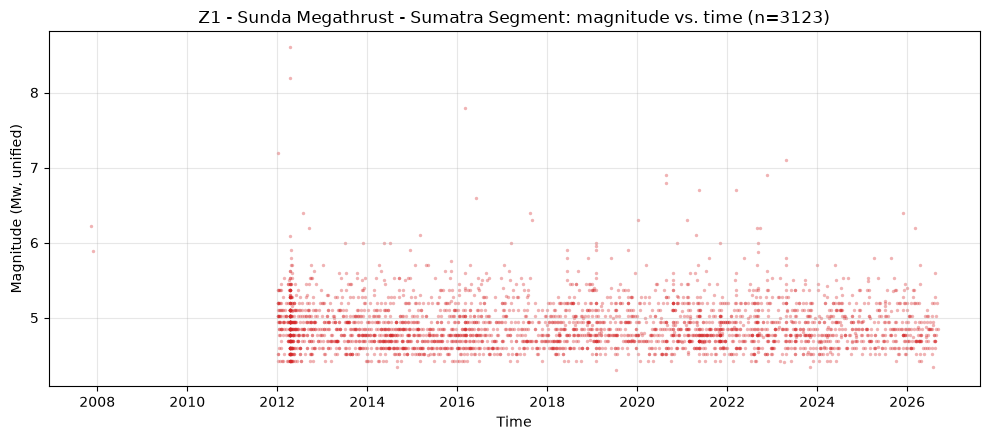

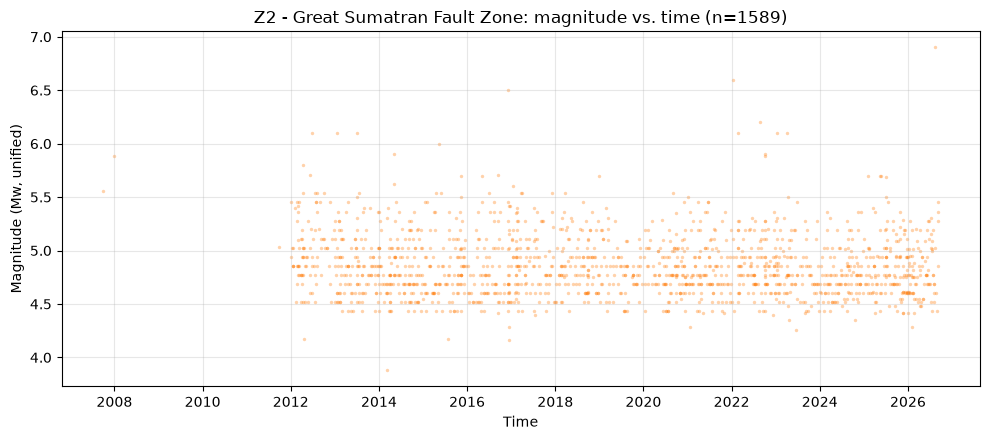

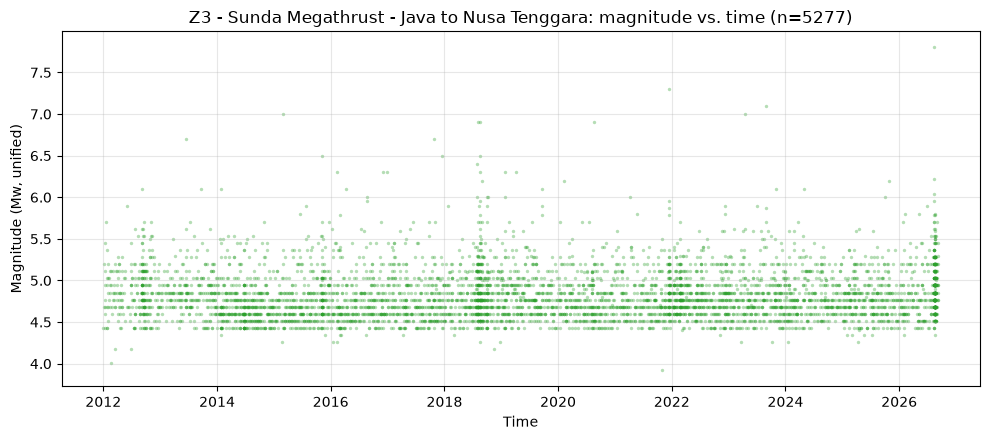

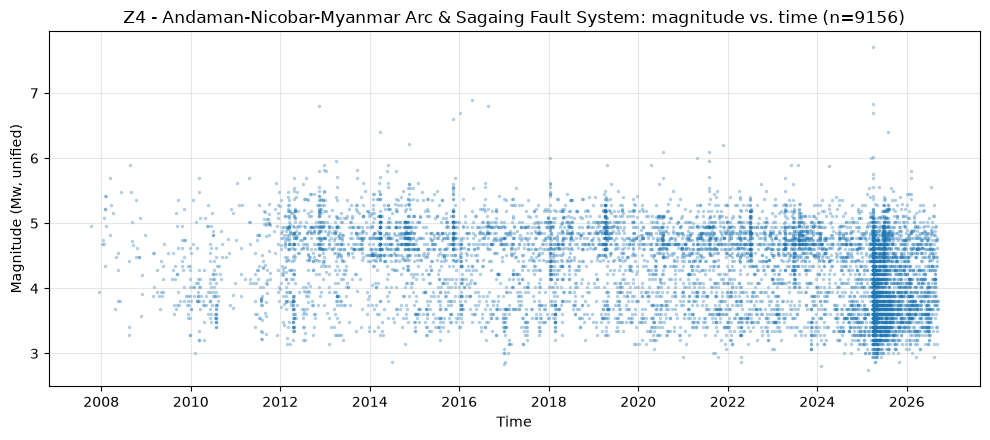

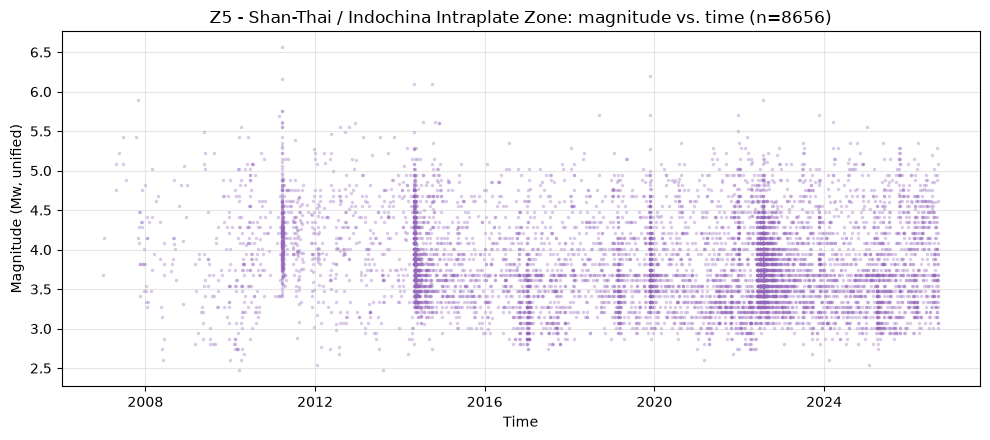

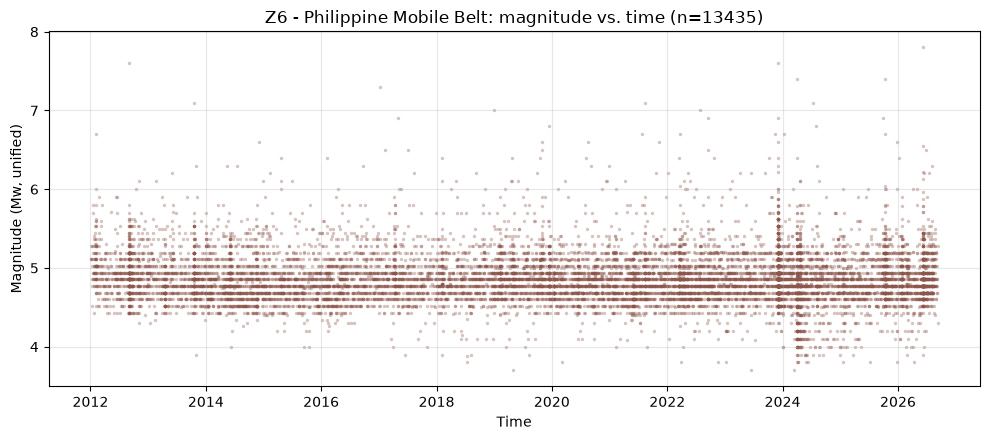

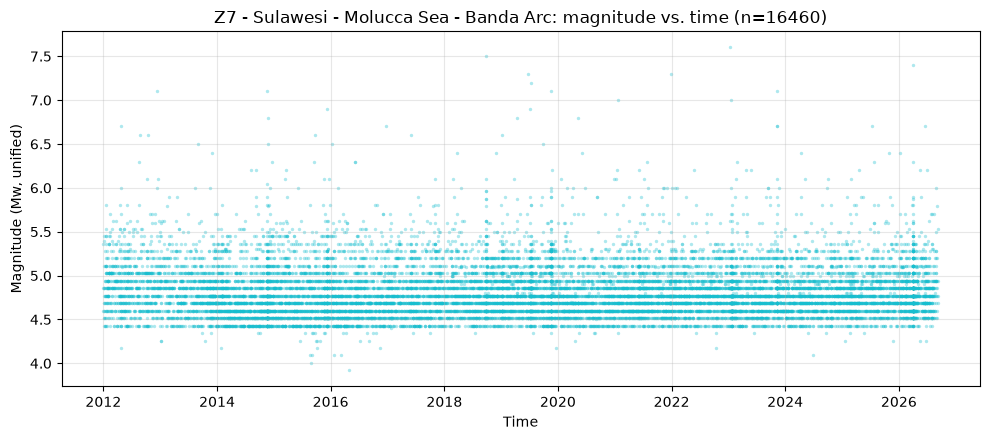

In [10]:
for zone in ZONE_ORDER:
    sub = catalog[catalog["zone_code"] == zone]
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.scatter(sub["time_utc"], sub["mag_unified"], s=6, alpha=0.35, color=ZONE_COLOR[zone], linewidths=0)
    ax.set_xlabel("Time")
    ax.set_ylabel("Magnitude (Mw, unified)")
    ax.set_title(f"{zone} - {ZONE_NAME[zone]}: magnitude vs. time (n={len(sub)})")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/mag_vs_time_{zone}.png", dpi=150)
    plt.show()


## 6. Event count vs. time per source zone (7 graphs)

Events per year, one bar chart per zone, saved separately
(`figures_v2/count_vs_time_<zone>.png`). Useful alongside Step 5 to see
whether magnitude trends coincide with changes in detection rate (network
build-out) rather than real seismicity changes.


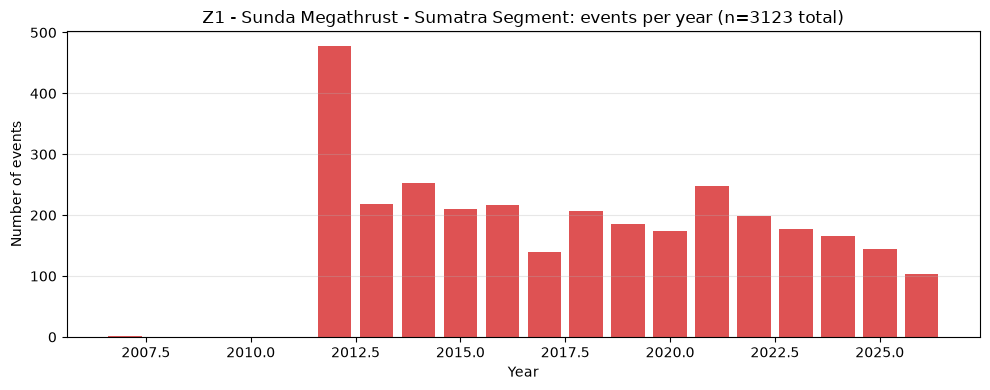

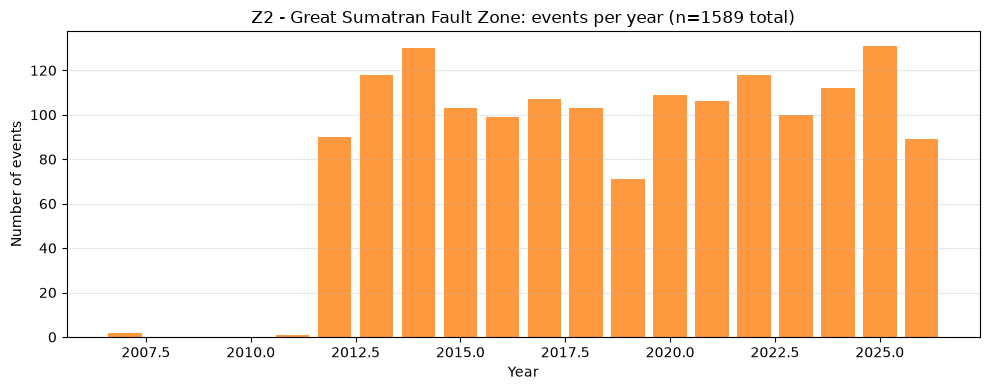

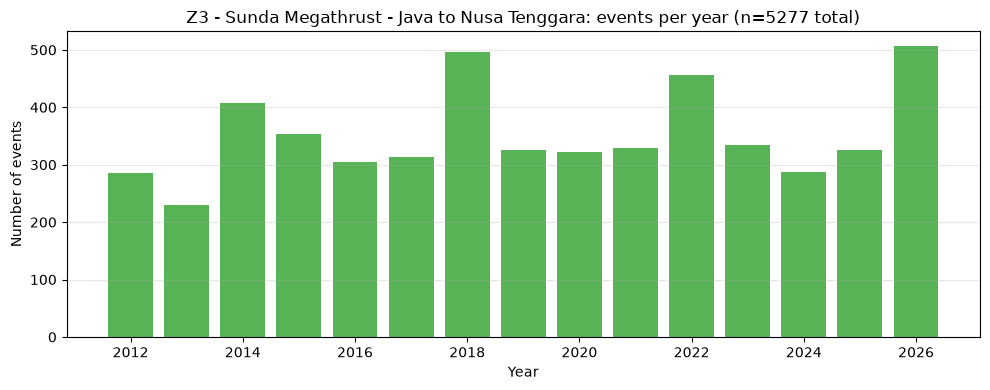

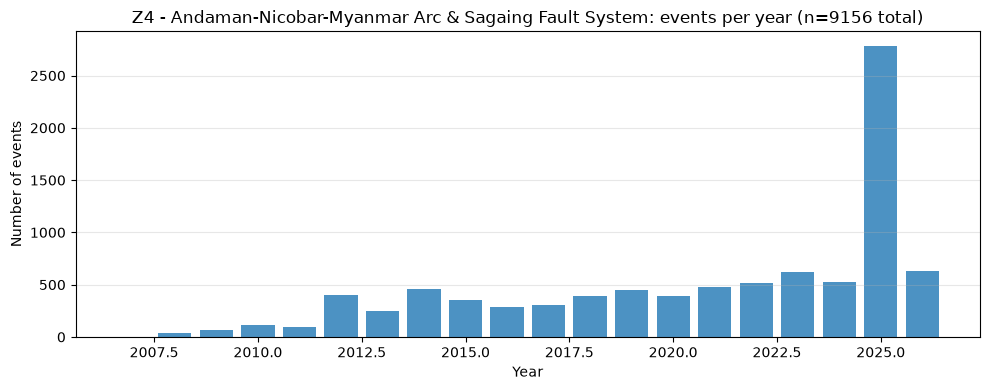

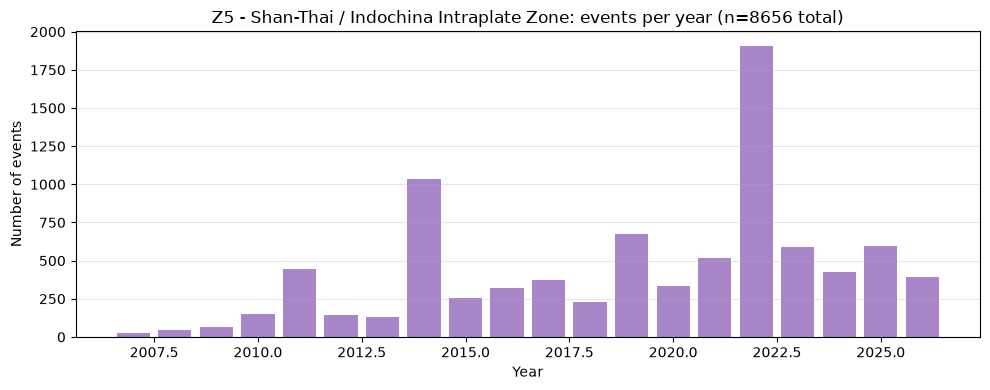

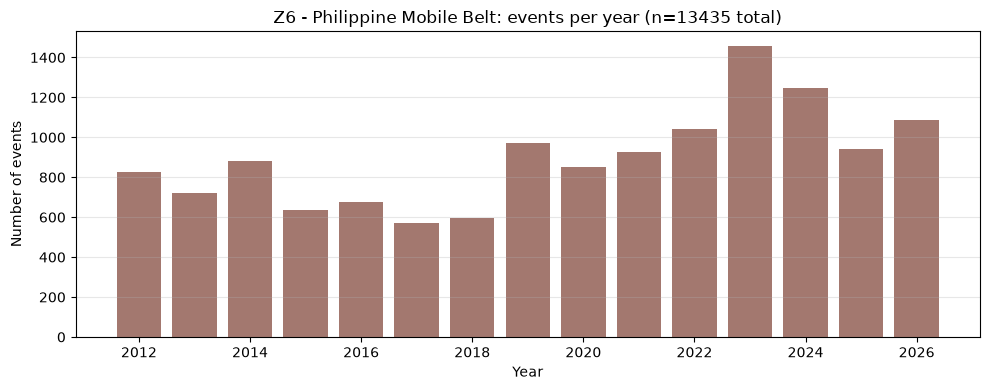

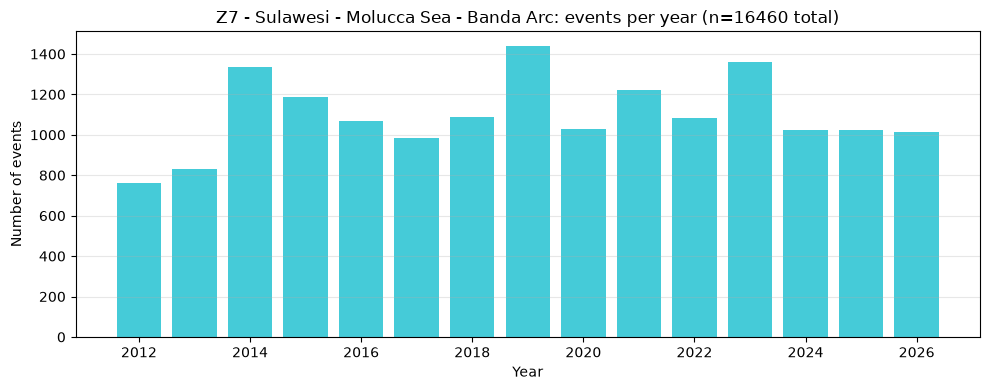

In [11]:
catalog["year"] = catalog["time_utc"].dt.year
for zone in ZONE_ORDER:
    sub = catalog[catalog["zone_code"] == zone]
    counts = sub.groupby("year").size()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(counts.index, counts.values, color=ZONE_COLOR[zone], alpha=0.8)
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of events")
    ax.set_title(f"{zone} - {ZONE_NAME[zone]}: events per year (n={len(sub)} total)")
    ax.grid(alpha=0.3, axis="y")
    fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/count_vs_time_{zone}.png", dpi=150)
    plt.show()


## 7. Resolution map — spatial data completeness (1 graph)

Divides the study region into a 1°x1° grid and computes the local magnitude
of completeness (Mc, via the maximum-curvature method) within each cell
that has at least `MIN_EVENTS_PER_CELL` events. This is a standard network-
resolution diagnostic (cf. Wiemer & Wyss, 2000): cells with low Mc are
where the catalog can resolve smaller earthquakes (better station coverage
/ denser monitoring); cells left blank don't have enough events to estimate
Mc at all (offshore/remote areas, sparse network coverage).


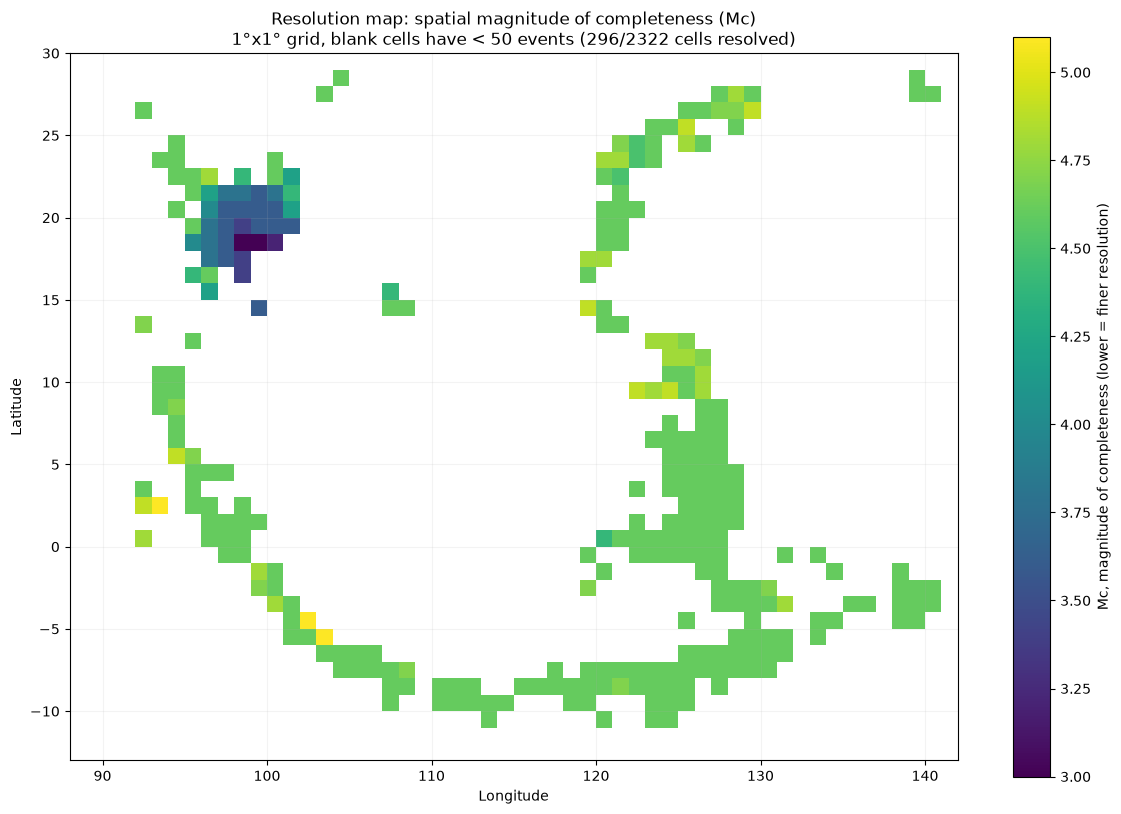

In [12]:
MIN_EVENTS_PER_CELL = 50
LAT_EDGES = np.arange(-13, 31, 1.0)
LON_EDGES = np.arange(88, 143, 1.0)


def max_curvature_mc(mags, dm=0.1):
    if len(mags) == 0:
        return np.nan
    bins = np.arange(np.floor(mags.min() / dm) * dm, mags.max() + dm, dm)
    counts, edges = np.histogram(mags, bins=bins)
    if counts.sum() == 0:
        return np.nan
    return edges[np.argmax(counts)]


lat_idx = np.digitize(catalog["lat"], LAT_EDGES) - 1
lon_idx = np.digitize(catalog["lon"], LON_EDGES) - 1
valid = (lat_idx >= 0) & (lat_idx < len(LAT_EDGES) - 1) & (lon_idx >= 0) & (lon_idx < len(LON_EDGES) - 1)
grid_df = catalog.loc[valid, ["mag_unified"]].copy()
grid_df["lat_idx"] = lat_idx[valid]
grid_df["lon_idx"] = lon_idx[valid]

mc_grid = np.full((len(LAT_EDGES) - 1, len(LON_EDGES) - 1), np.nan)
count_grid = np.zeros_like(mc_grid)
for (i, j), grp in grid_df.groupby(["lat_idx", "lon_idx"]):
    mags = grp["mag_unified"].dropna().values
    count_grid[i, j] = len(mags)
    if len(mags) >= MIN_EVENTS_PER_CELL:
        mc_grid[i, j] = max_curvature_mc(mags)

fig, ax = plt.subplots(figsize=(12, 9))
pcm = ax.pcolormesh(LON_EDGES, LAT_EDGES, mc_grid, cmap="viridis", shading="flat")
cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
cbar.set_label("Mc, magnitude of completeness (lower = finer resolution)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
n_resolved = np.isfinite(mc_grid).sum()
n_total = mc_grid.size
ax.set_title(f"Resolution map: spatial magnitude of completeness (Mc)\n"
             f"1°x1° grid, blank cells have < {MIN_EVENTS_PER_CELL} events "
             f"({n_resolved}/{n_total} cells resolved)")
ax.set_aspect("equal")
ax.grid(alpha=0.15)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/resolution_map.png", dpi=150)
plt.show()


### 7b. Resolution map, alternate view — events colored by local resolution, with zone regions

Same idea as the grid heatmap above, but painted onto the actual events
(each point takes the Mc of the 1°x1° cell it falls in) on a basemap with
the 7 seismic source zones outlined and numbered, styled after a reference
catalog map. Gray points fall in cells with too few events (<
`MIN_EVENTS_PER_CELL`) to estimate a local Mc. Zone outlines here are
simple rectangles for display only (Z1/Z2 approximate the diagonal
Sumatra split from `classify()` as boxes); the real, non-rectangular
boundaries are what actually assigned `zone_code` in Step 4.

Requires `cartopy` (`pip install cartopy`) for the coastline/border
basemap; it downloads Natural Earth shapefiles the first time it runs
(cached afterward).


Events with resolvable local Mc: 52699 / 62506


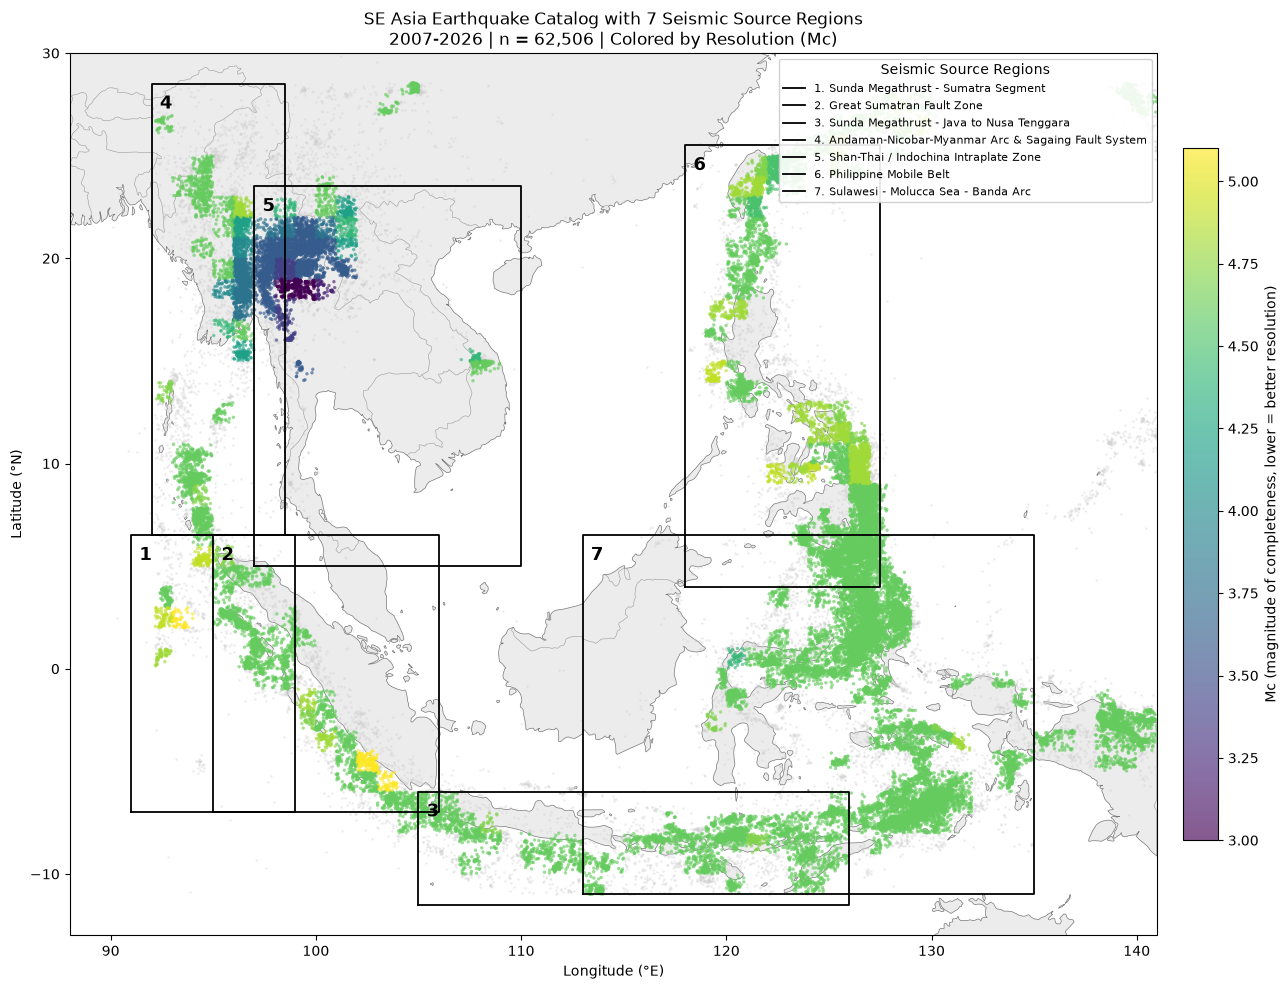

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.lines as mlines

# Simplified rectangular outlines for display only (Z1/Z2 approximate the
# diagonal Sumatra split as boxes; Z3-Z7 match classify()'s real boxes).
ZONE_BOX = {
    "Z1": (91, 99, -7, 6.5),
    "Z2": (95, 106, -7, 6.5),
    "Z3": (105, 126, -11.5, -6.0),
    "Z4": (92, 98.5, 6.5, 28.5),
    "Z5": (97, 110, 5.0, 23.5),
    "Z6": (118, 127.5, 4.0, 25.5),
    "Z7": (113, 135, -11.0, 6.5),
}

# Reuse the mc_grid computed above: look up each event's local Mc via its grid cell
resolution = np.full(len(catalog), np.nan)
resolution[valid] = mc_grid[lat_idx[valid], lon_idx[valid]]
catalog["resolution_mc"] = resolution
has_res = catalog["resolution_mc"].notna()
print(f"Events with resolvable local Mc: {has_res.sum()} / {len(catalog)}")

fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([88, 141, -13, 30], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#ececec", zorder=0)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="#999999", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="#777777", zorder=1)

ax.scatter(catalog.loc[~has_res, "lon"], catalog.loc[~has_res, "lat"], color="#cfcfcf", s=3, alpha=0.4,
           linewidths=0, transform=ccrs.PlateCarree(), zorder=2)
sc = ax.scatter(catalog.loc[has_res, "lon"], catalog.loc[has_res, "lat"],
                 c=catalog.loc[has_res, "resolution_mc"], cmap="viridis", s=6, alpha=0.65,
                 linewidths=0, transform=ccrs.PlateCarree(), zorder=3)

for i, zone in enumerate(ZONE_ORDER, start=1):
    lon0, lon1, lat0, lat1 = ZONE_BOX[zone]
    ax.plot([lon0, lon1, lon1, lon0, lon0], [lat0, lat0, lat1, lat1, lat0],
            color="black", linewidth=1.3, transform=ccrs.PlateCarree(), zorder=4)
    ax.text(lon0 + 0.4, lat1 - 1.2, str(i), fontsize=13, fontweight="bold", color="black",
            transform=ccrs.PlateCarree(), zorder=5)

cbar = fig.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label("Mc (magnitude of completeness, lower = better resolution)")

legend_handles = [mlines.Line2D([], [], color="black", linewidth=1.3) for _ in ZONE_ORDER]
legend_labels = [f"{i}. {ZONE_NAME[z]}" for i, z in enumerate(ZONE_ORDER, start=1)]
ax.legend(legend_handles, legend_labels, loc="upper right", fontsize=8, framealpha=0.9, title="Seismic Source Regions")

n_years = f"{catalog['time_utc'].min().year}-{catalog['time_utc'].max().year}"
ax.set_title(f"SE Asia Earthquake Catalog with 7 Seismic Source Regions\n"
             f"{n_years} | n = {len(catalog):,} | Colored by Resolution (Mc)")
ax.set_xticks(np.arange(90, 141, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-10, 31, 10), crs=ccrs.PlateCarree())
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/resolution_by_zone_map.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Summary

- Preprocess: merged TMD + USGS, deduped, unified to Mw, audited for
  missing/dropped data, and labeled every event by 1 of 7 tectonic plates.
- EDA: 7 magnitude-vs-time graphs, 7 count-vs-time graphs, and 1 resolution
  map, all saved to `figures_v2/`.
- Outputs: `data/processed/catalog_clean_unified_zoned.csv` is the final
  catalog this notebook produces (unified Mw + zone labels), ready for the
  next stage (mainshock-aftershock declustering + spatial probability
  modeling).
